# argentina.telefonos — Limpieza de un dataset real

Recorrido **usando el paquete** sobre el caso típico: una columna de teléfonos en distintos formatos sale de un formulario o un CRM, y hay que limpiarla, validarla y normalizarla a E.164 antes de exportarla o cruzarla.

Pipeline:

1. Cargar lote sucio.
2. Limpiar y discriminar celular vs fijo.
3. Extraer característica y mapear a provincia (heurística local).
4. Normalizar a E.164.
5. Marcar inválidos.
6. Resumen y gráfico de distribución por provincia.

## 1. Setup

In [1]:
import argentina as arg
import pandas as pd
import matplotlib.pyplot as plt

print(f"argentina v{arg.__version__}")

argentina v0.0.19


## 2. Lote crudo

Mezcla típica de formatos que aparecen en datasets reales: con/sin `+54`, con/sin `9`/`15`, con paréntesis, con guiones, mayúsculas, espacios, basura, vacíos.

In [2]:
crudo = [
    "+54 9 11 1234-5678",
    "011 4321-1234",
    "(011) 15 1234-5678",
    "54 9 351 1234567",
    "+54 261 4123456",
    "011-4123-9876",
    "0341 15 5555-1234",
    "+5491156789012",
    "0387 4 222111",
    "299 4123456",
    "351 15 7000000",
    " ",
    "chau",
    None,
    "+54 11 1234 5678",
    "+54 9 11 1234 5678 extension 22",
]

df = pd.DataFrame({'crudo': crudo})
df.head(20)

,crudo
0,+54 9 11 1234-5678
1,011 4321-1234
2,(011) 15 1234-5678
3,54 9 351 1234567
4,+54 261 4123456
5,011-4123-9876
6,0341 15 5555-1234
7,+5491156789012
8,0387 4 222111
9,299 4123456


## 3. Limpieza, clasificación y normalización

Aplicamos todas las funciones de `arg.telefonos` en simultáneo.

In [3]:
df['solo_digitos']    = df['crudo'].apply(arg.telefonos.limpiar)
df['valido']          = df['crudo'].apply(arg.telefonos.validar)
df['celular']         = df['crudo'].apply(arg.telefonos.es_celular)
df['caracteristica']  = df['crudo'].apply(arg.telefonos.extraer_caracteristica)
df['e164']            = df['crudo'].apply(arg.telefonos.normalizar_e164)
df

,crudo,solo_digitos,valido,celular,caracteristica,e164
0,+54 9 11 1234-5678,5491112345678,True,True,11,+5491112345678
1,011 4321-1234,01143211234,True,False,11,+541143211234
2,(011) 15 1234-5678,0111512345678,True,True,11,+5491112345678
3,54 9 351 1234567,5493511234567,True,True,351,+5493511234567
4,+54 261 4123456,542614123456,True,False,261,+542614123456
5,011-4123-9876,01141239876,True,False,11,+541141239876
6,0341 15 5555-1234,03411555551234,False,False,341,None
7,+5491156789012,5491156789012,True,True,11,+5491156789012
8,0387 4 222111,03874222111,True,False,387,+543874222111
9,299 4123456,2994123456,True,False,299,+542994123456


## 4. Tasa de validez y mix celular/fijo

In [4]:
total = len(df)
validos = df['valido'].sum()
celus = df[df['valido']]['celular'].sum()
fijos = validos - celus
invalidos = total - validos

print(f"Total filas:     {total}")
print(f"Válidos:         {validos}  ({validos/total:.0%})")
print(f"  - celulares:   {celus}")
print(f"  - fijos:       {fijos}")
print(f"Inválidos:       {invalidos}")

Total filas:     16
Válidos:         11  (69%)
  - celulares:   5
  - fijos:       6
Inválidos:       5


In [5]:
# Filas que no superaron la validación → revisar manualmente
df[~df['valido']][['crudo', 'solo_digitos']]

,crudo,solo_digitos
6,0341 15 5555-1234,03411555551234
11,,None
12,chau,None
13,None,None
15,+54 9 11 1234 5678 extension 22,549111234567822


## 5. De característica a provincia

Las características telefónicas argentinas no son parte oficial del paquete (cambian poco pero hay excepciones por localidad). Para este análisis usamos un mapeo manual de las principales:

In [6]:
AREA_A_PROVINCIA = {
    '11':  'Buenos Aires / CABA',
    '221': 'Buenos Aires',
    '223': 'Buenos Aires',
    '261': 'Mendoza',
    '264': 'San Juan',
    '266': 'San Luis',
    '291': 'Buenos Aires',
    '297': 'Chubut',
    '299': 'Neuquén',
    '341': 'Santa Fe',
    '342': 'Santa Fe',
    '343': 'Entre Ríos',
    '351': 'Córdoba',
    '362': 'Chaco',
    '370': 'Formosa',
    '376': 'Misiones',
    '379': 'Corrientes',
    '380': 'La Rioja',
    '381': 'Tucumán',
    '383': 'Catamarca',
    '385': 'Santiago del Estero',
    '387': 'Salta',
    '388': 'Jujuy',
}

df['provincia'] = df['caracteristica'].map(AREA_A_PROVINCIA)
df[df['valido']][['crudo', 'e164', 'caracteristica', 'provincia']]

,crudo,e164,caracteristica,provincia
0,+54 9 11 1234-5678,+5491112345678,11,Buenos Aires / CABA
1,011 4321-1234,+541143211234,11,Buenos Aires / CABA
2,(011) 15 1234-5678,+5491112345678,11,Buenos Aires / CABA
3,54 9 351 1234567,+5493511234567,351,Córdoba
4,+54 261 4123456,+542614123456,261,Mendoza
5,011-4123-9876,+541141239876,11,Buenos Aires / CABA
7,+5491156789012,+5491156789012,11,Buenos Aires / CABA
8,0387 4 222111,+543874222111,387,Salta
9,299 4123456,+542994123456,299,Neuquén
10,351 15 7000000,+5493517000000,351,Córdoba


## 6. Distribución del lote

In [7]:
por_prov = df[df['valido']]['provincia'].value_counts()
por_prov

provincia
Buenos Aires / CABA    6
Córdoba                2
Mendoza                1
Salta                  1
Neuquén                1
Name: count, dtype: int64

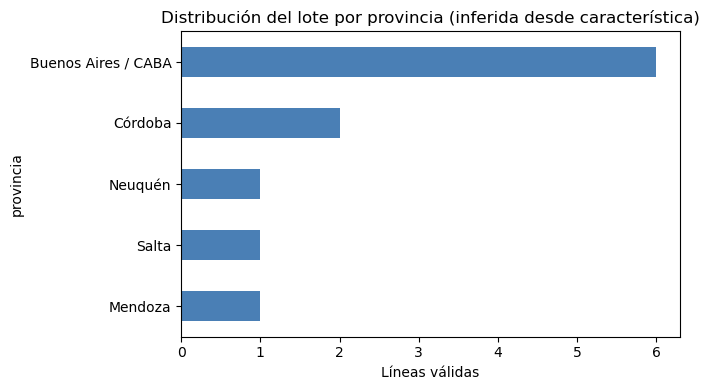

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
por_prov.sort_values().plot.barh(ax=ax, color='#4a7fb5')
ax.set_xlabel('Líneas válidas')
ax.set_title('Distribución del lote por provincia (inferida desde característica)')
plt.tight_layout()
plt.show()

## 7. Exportar el dataset normalizado

Quedan dos columnas listas para el sistema downstream: `e164` (canónica) y `provincia` (enriquecida).

In [9]:
limpio = df[df['valido']][['crudo', 'e164', 'celular', 'provincia']].reset_index(drop=True)
limpio

,crudo,e164,celular,provincia
0,+54 9 11 1234-5678,+5491112345678,True,Buenos Aires / CABA
1,011 4321-1234,+541143211234,False,Buenos Aires / CABA
2,(011) 15 1234-5678,+5491112345678,True,Buenos Aires / CABA
3,54 9 351 1234567,+5493511234567,True,Córdoba
4,+54 261 4123456,+542614123456,False,Mendoza
5,011-4123-9876,+541141239876,False,Buenos Aires / CABA
6,+5491156789012,+5491156789012,True,Buenos Aires / CABA
7,0387 4 222111,+543874222111,False,Salta
8,299 4123456,+542994123456,False,Neuquén
9,351 15 7000000,+5493517000000,True,Córdoba


In [10]:
# Forzar todos como celular si el negocio lo requiere
df['e164_forzando_celular'] = df['crudo'].apply(
    lambda v: arg.telefonos.normalizar_e164(v, celular=True)
)
df[df['valido']][['crudo', 'e164', 'e164_forzando_celular']]

,crudo,e164,e164_forzando_celular
0,+54 9 11 1234-5678,+5491112345678,+5491112345678
1,011 4321-1234,+541143211234,+5491143211234
2,(011) 15 1234-5678,+5491112345678,+5491112345678
3,54 9 351 1234567,+5493511234567,+5493511234567
4,+54 261 4123456,+542614123456,+5492614123456
5,011-4123-9876,+541141239876,+5491141239876
7,+5491156789012,+5491156789012,+5491156789012
8,0387 4 222111,+543874222111,+5493874222111
9,299 4123456,+542994123456,+5492994123456
10,351 15 7000000,+5493517000000,+5493517000000


## Notas

- `arg.telefonos` es sintáctico: limpia, normaliza largo y discrimina celular/fijo por patrones (`9`, `15`). NO consulta operadores ni valida que la línea exista físicamente.
- El mapeo característica → provincia de esta notebook es **demo**, no parte de la API del paquete. Las características reales tienen excepciones por localidad.
- `normalizar_e164` con `celular=True/False` es útil cuando el origen del dato ya garantiza el tipo (ej: WhatsApp Business solo acepta celulares con `+549`).